# Kernel Convergence Test

This notebook provides a minimal example to verify that the empirical NTK of the P4-equivariant architecture
converges to the theoretical infinite-width kernel as the network width increases. Inputs and model architecture are chosen for quick demonstrative purposes only.

**Setup**: two fixed random 16×16 images; for each network width we draw `N_SAMPLES`
independent parameter initialisations, compute the 2×2 empirical NTK/NNGP Gram matrix,
and compare it against the analytic infinite-width kernel.

In [1]:
import jax
import jax.numpy as jnp
import neural_tangents as nt
from neural_tangents import stax
from neural_tangents.stax import Padding
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import bootstrap
from functools import partial
from equivariant_ntk.layers import GroupPool, P4ConvP4, Z2ConvP4

SEED = 0xDEADBEEF

## Architecture

The $C_4 \ltimes \mathbb{R}^2$ CNN lifts starts with the lifting layer 
(`Z2ConvP4`) that takes a 2D image and outputs 2D images over the group domain $C_4$. Consecutive equivariant layers acting on this spacea are instantiations of (`P4ConvP4`).  The
`GroupPool` layer averages over all group and spatial dimensions.

In [2]:
def make_p4cnn(width):
    """P4-equivariant CNN with variable channel width."""
    return stax.serial(
        Z2ConvP4(width, (3, 3), padding=Padding.SAME),
        stax.Relu(),
        P4ConvP4(width, (3, 3), padding=Padding.SAME),
        stax.Relu(),
        GroupPool(),
        stax.Dense(9),
    )

## Inputs and Infinite-Width Kernel

We fix the two random input images once and reuse them for all widths.

In [3]:
# Fixed random inputs: batch of 2 images, 16×16 pixels, 3 channels
key = jax.random.key(SEED)
key, input_key = jax.random.split(key)
x = jax.random.normal(input_key, (2, 16, 16, 3))

# Analytic infinite-width kernels (width-independent in NTK parameterisation)
_, _, kernel_fn = make_p4cnn(width=1)
k_inf_ntk  = kernel_fn(x, None, 'ntk')
k_inf_nngp = kernel_fn(x, None, 'nngp')

print("Infinite-width NTK (2×2):");  print(k_inf_ntk)
print("Infinite-width NNGP (2×2):"); print(k_inf_nngp)

Infinite-width NTK (2×2):
[[0.14003834 0.137896  ]
 [0.137896   0.13856379]]
Infinite-width NNGP (2×2):
[[0.09886191 0.09804619]
 [0.09804619 0.09776222]]


## Monte-Carlo Estimation

For each width we draw `N_SAMPLES` independent parameter initialisations and collect
the empirical kernel matrices as samples (shape `N_SAMPLES × 2 × 2`). Samples are computed in batches in parallel using `vmap`. For wider networks the memory requirements of the kernel computation can become prohibitively expensive. Reduce the batch size in that case.

Then the sample-mean is used to compute the relative deviation to the infinite-width kernel.
Error bars are estimated via `scipy.stats.bootstrap` with `N_BOOT` resamples.

In [4]:
WIDTHS     = [1, 2, 4, 8]
N_SAMPLES  = 100
N_BOOT     = 50
BATCH_SIZE = 5   # number of samples per vmap call; reduce if memory is tight


results_ntk  = {}  # width -> {'mean', 'ci_low', 'ci_high'}
results_nngp = {}

for width in WIDTHS:
    init_fn, apply_fn, _ = make_p4cnn(width)
    ntk_fn  = nt.empirical_ntk_fn( f=apply_fn, trace_axes=(-1,), vmap_axes=0)
    nngp_fn = nt.empirical_nngp_fn(f=apply_fn, trace_axes=(-1,))

    def single_kernel_sample(subkey):
        _, params = init_fn(subkey, x.shape)
        return ntk_fn(x, None, params), nngp_fn(x, None, params)

    sample_batch = jax.jit(jax.vmap(single_kernel_sample))

    # Draw N_SAMPLES empirical kernel matrices in batches: shape (N_SAMPLES, 2, 2)
    key, sample_key = jax.random.split(key)
    subkeys = jax.random.split(sample_key, N_SAMPLES)

    ntk_batches, nngp_batches = [], []
    for i in range(0, N_SAMPLES, BATCH_SIZE):
        ntk_b, nngp_b = sample_batch(subkeys[i:i + BATCH_SIZE])
        ntk_batches .append(np.array(ntk_b))
        nngp_batches.append(np.array(nngp_b))

    ntk_samples  = np.concatenate(ntk_batches,  axis=0)  # (N_SAMPLES, 2, 2)
    nngp_samples = np.concatenate(nngp_batches, axis=0)

    def make_estimator_fn(k_inf):
        """Vectorized bootstrap statistic.

        scipy (vectorized=True) appends N_BOOT as a trailing dim, so samples has
        shape (N_SAMPLES, 2, 2, N_BOOT) and axis=0.  After the mean over axis=0 we
        get (2, 2, N_BOOT).
        """
        k_inf = np.array(k_inf)
        def estimate_mean_relative_deviation(samples, axis):
            k_mean  = np.mean(samples, axis=axis)
            k_inf_b = np.expand_dims(k_inf, axis=-1) if k_mean.ndim > k_inf.ndim else k_inf
            rel_err = np.abs(k_mean - k_inf_b) / np.abs(k_inf_b)
            return np.mean(rel_err, axis=(0, 1))            # → scalar or (N_BOOT,)
        return estimate_mean_relative_deviation

    for samples, k_inf, store in [
        (ntk_samples,  k_inf_ntk,  results_ntk),
        (nngp_samples, k_inf_nngp, results_nngp),
    ]:
        stat_fn = make_estimator_fn(k_inf)
        bs = bootstrap(
            (samples,), stat_fn,
            n_resamples=N_BOOT,
            axis=0,
            vectorized=True,
            random_state=0,
        )
        store[width] = {
            'mean':    float(stat_fn(samples, axis=0)),
            'ci_low':  float(bs.confidence_interval.low),
            'ci_high': float(bs.confidence_interval.high),
        }

    print(
        f"width={width:3d}:  "
        f"NTK  {results_ntk [width]['mean']:.4f} "
        f"[{results_ntk [width]['ci_low']:.4f}, {results_ntk [width]['ci_high']:.4f}]   "
        f"NNGP {results_nngp[width]['mean']:.4f} "
        f"[{results_nngp[width]['ci_low']:.4f}, {results_nngp[width]['ci_high']:.4f}]"
    )

width=  1:  NTK  0.1591 [0.0448, 0.5166]   NNGP 0.1366 [0.0218, 0.5502]
width=  2:  NTK  0.0221 [0.0057, 0.0753]   NNGP 0.0401 [0.0084, 0.1735]
width=  4:  NTK  0.0433 [0.0056, 0.1221]   NNGP 0.0911 [0.0041, 0.2062]
width=  8:  NTK  0.0538 [0.0040, 0.1462]   NNGP 0.0489 [0.0025, 0.1535]


## Convergence Plot

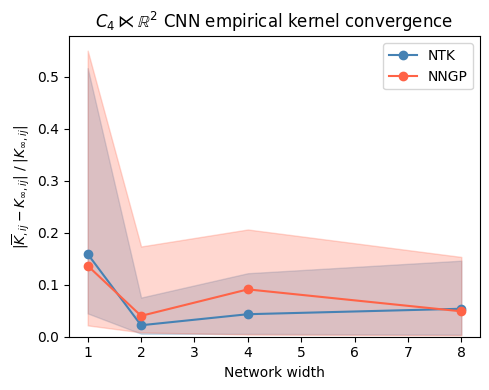

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))

for results, label, color in [
    (results_ntk,  'NTK',  'steelblue'),
    (results_nngp, 'NNGP', 'tomato'),
]:
    means   = np.array([results[w]['mean']    for w in WIDTHS])
    ci_low  = np.array([results[w]['ci_low']  for w in WIDTHS])
    ci_high = np.array([results[w]['ci_high'] for w in WIDTHS])

    ax.plot(WIDTHS, means, 'o-', color=color, label=label)
    ax.fill_between(WIDTHS, ci_low, ci_high, alpha=0.25, color=color)

ax.set_xlabel('Network width')
ax.set_ylabel(r'$|\overline{K}_{,ij} - K_{\infty,ij}|\;/\;|K_{\infty,ij}|$')
ax.set_title(r'$C_4 \ltimes \mathbb{R}^2$ CNN empirical kernel convergence')
ax.set_ylim(bottom=0)
ax.legend()

plt.tight_layout()
plt.savefig('kernel_convergence.png', dpi=150, bbox_inches='tight')
plt.show()